# Downstream volatility forecasting

This notebook connects the HMM-Diffusion stitched return series to a downstream volatility forecast. A random forest predicts future realized volatility from current vol and technical indicators. Training mixes real and synthetic rows; evaluation always uses a held-out real test set.

Run scripts 01 and 04 first, and install ta from requirements.txt. This notebook fits the supervised HMM only.


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config
from hmmdiff import data, models, plots, pools, stitch
from hmmdiff.downstream import (
    build_aligned_downstream_synth,
    compute_returns,
    load_real_benchmark,
    train_model_and_evaluate_advanced_volatility_mixture,
)
from hmmdiff.regimes import load_labels

bootstrap_imports()
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_context("notebook")

cfg = load_config()
N_REGIMES = int(cfg["regimes"]["n_regimes"])
TOP_K = int(cfg["hmm"]["top_k"])
PRICE_COL = cfg["data"]["price_column"]
TEST_START_YEAR = "2014"
HORIZONS = [1, 10, 20]
MIX_GRID = list(range(0, 101, 10))
RANDOM_STATE = 42

## Build the synthetic price path

Load diffusion pools with global z-score and per-regime calibration. Fit the supervised HMM on pre-2014 inner training data. Estimate regimes on real 2014+ z-scored returns, stitch pool draws along that path, and integrate into prices anchored at the real benchmark start.


In [2]:
returns = data.load_returns(cfg)
labels = load_labels(config_path(cfg, "regime_labels"))
train_data, val_data = data.build_model_frames(returns, labels.labels, cfg)
splits = data.compute_splits(len(returns), cfg)
val_regimes = labels.labels[splits.train_val_split : splits.train_val_split + len(val_data)]

pools_root = config_path(cfg, "pools")
using_placeholder = not pools.pools_available(pools_root, N_REGIMES)
GENERATED_TITLE = (
    "PLACEHOLDER: Resampled Real Returns (not diffusion)"
    if using_placeholder
    else "HMM Diffusion Generated Returns"
)
if using_placeholder:
    print("WARNING: using placeholder pools (resampled real returns)")
    generated_images = pools.placeholder_pools(
        train_data.emission.values,
        train_data.regime.values,
        N_REGIMES,
        size=len(train_data),
        seed=0,
    )
else:
    regime_stats = pools.regime_emission_stats(
        train_data.emission.values, train_data.regime.values, N_REGIMES
    )
    generated_images = pools.load_generated_images(
        pools_root,
        N_REGIMES,
        returns=returns,
        calibrate_regimes=regime_stats,
    )

init_dist = models.initial_distribution(train_data, N_REGIMES)
supervised = models.fit_supervised_hmm(train_data, N_REGIMES, cfg)

df_real = load_real_benchmark(cfg, test_start_year=TEST_START_YEAR, price_col=PRICE_COL)
aligned = build_aligned_downstream_synth(
    returns=returns,
    generated_images=generated_images,
    supervised=supervised,
    init_dist=init_dist,
    n_regimes=N_REGIMES,
    df_real=df_real,
    price_col=PRICE_COL,
)
df_synth = aligned.df_synth

common = df_real.index.intersection(df_synth.index)
df_real = df_real.loc[common]
df_synth = df_synth.loc[common]
benchmark = aligned

start_price = float(df_synth[PRICE_COL].iloc[0])
print(
    f"Aligned synthetic: {df_synth.index.min().date()} → {df_synth.index.max().date()} "
    f"({len(df_synth):,} trading days), start_price={start_price:,.2f}"
)
print(f"HMM fit on inner train: {len(train_data):,} days (pre-2014)")

100%|██████████| 2258/2258 [00:00<00:00, 97673.74it/s]
2258it [00:00, 93954.81it/s]

Aligned synthetic: 2014-01-06 → 2022-08-31 (2,258 trading days), start_price=7,091.52
HMM fit on inner train: 5,079 days (pre-2014)


In [3]:
real_returns_log = compute_returns(df_real, log=True, col=PRICE_COL)
synth_returns_log = compute_returns(df_synth, log=True, col=PRICE_COL)

print(
    f"Real benchmark panel: {df_real.index.min().date()} → {df_real.index.max().date()} "
    f"({len(df_real):,} trading days)"
)
display(df_real[[PRICE_COL, f"{PRICE_COL}_log"]].head())
display(df_synth[[PRICE_COL, f"{PRICE_COL}_log"]].head())

Real benchmark panel: 2014-01-06 → 2022-08-31 (2,258 trading days)


,A001,A001_log
2014-01-06,7091.52,8.866655
2014-01-07,7134.73,8.872730
2014-01-08,7135.35,8.872817
2014-01-09,7137.80,8.873160
2014-01-10,7154.29,8.875467


,A001,A001_log
2014-01-06,7091.520000,8.866655
2014-01-07,7114.228832,8.869852
2014-01-08,7137.437903,8.873109
2014-01-09,7148.786319,8.874698
2014-01-10,7138.576404,8.873269


## HMM stitch diagnostics

Same figures as HMM-Diffusion.ipynb for the supervised variant on inner train and validation. The 2014+ benchmark window has no Vol_Regime labels, so only estimated regimes and generated returns are shown there.


Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.997,0.002,0.001,0.000,0.000
1,0.001,0.997,0.001,0.001,0.000
2,0.001,0.002,0.994,0.002,0.001
3,0.000,0.000,0.011,0.988,0.000
4,0.002,0.001,0.002,0.012,0.983


Emission parameters


,mean,sigma
regime,,
0,0.008667,0.502795
1,0.020222,0.676420
2,0.004333,0.967187
3,-0.038348,1.382216
4,-0.035469,1.923118


100%|██████████| 5079/5079 [00:00<00:00, 88112.86it/s]
5079it [00:00, 94972.36it/s]
100%|██████████| 1694/1694 [00:00<00:00, 95679.38it/s]
1694it [00:00, 95265.02it/s]


Train accuracy  83.40%   top-2  96.69%
Val   accuracy  63.40%   top-2  90.50%


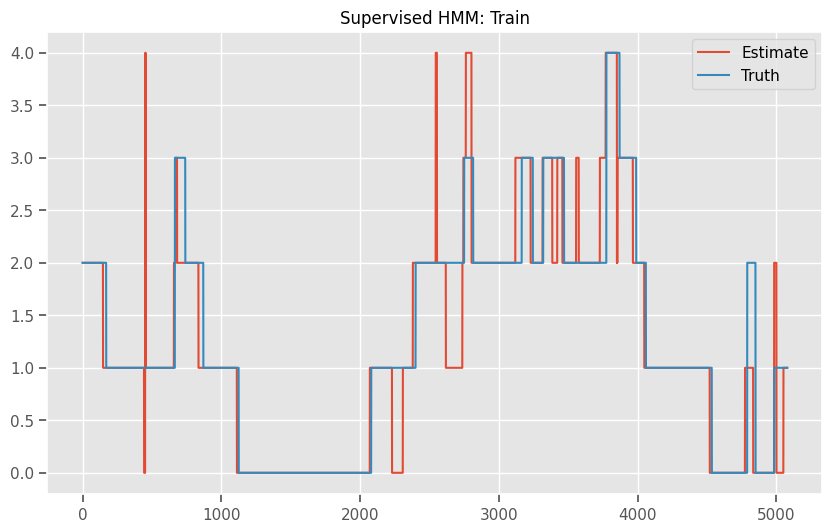

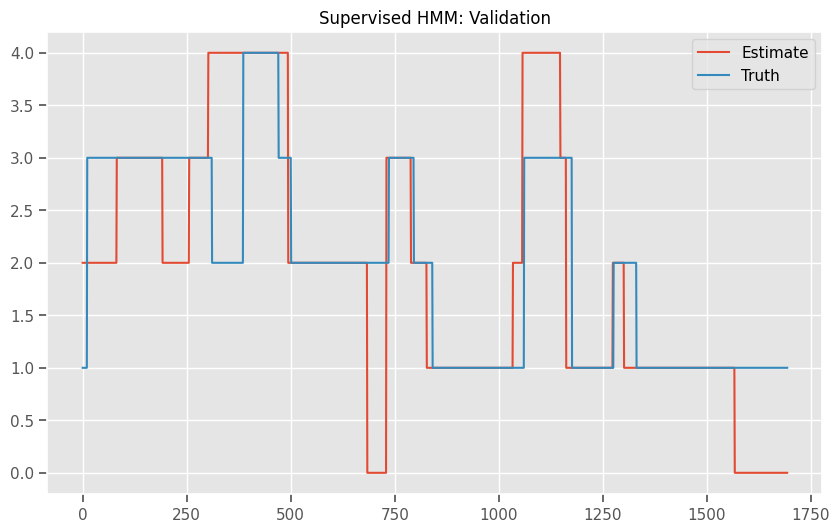

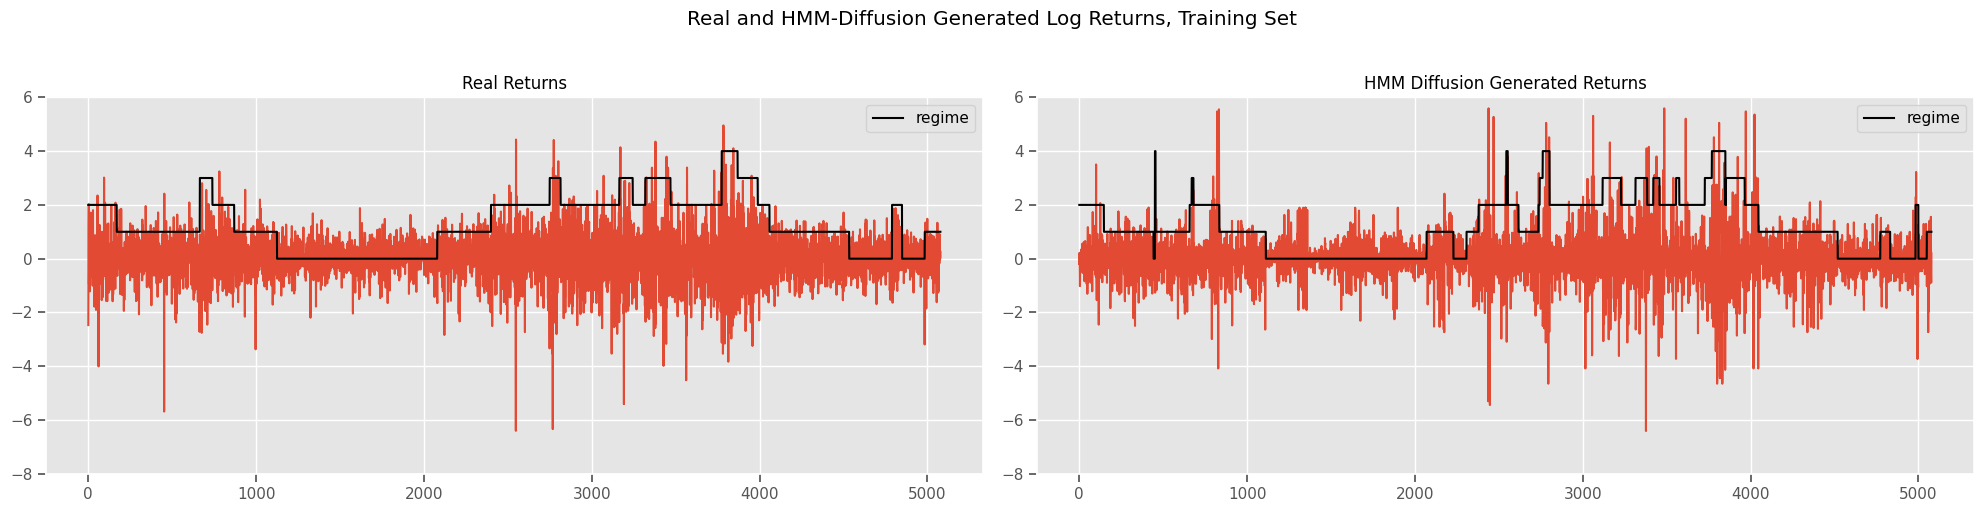

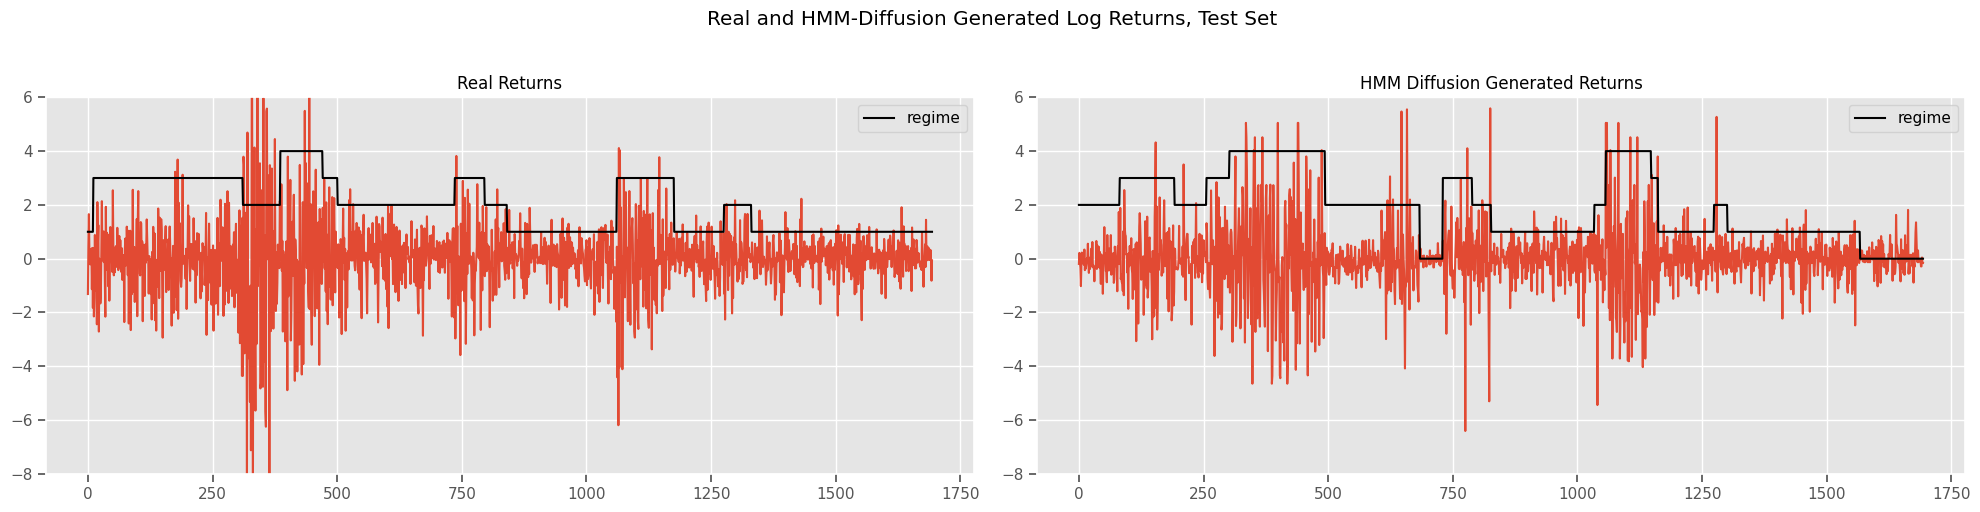

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1345,0.007529,0.007302,0.250809,0.273303
1,1639,0.019233,0.006300,0.456859,0.472522
2,1510,0.004431,-0.027734,0.939488,0.903428
3,490,-0.030662,-0.037253,1.883920,1.600384
4,95,-0.086016,-0.174232,3.644671,4.383560


Validation backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,0,NaN,NaN,NaN,NaN
1,694,0.020163,0.022144,0.440136,0.501727
2,410,-0.028887,0.042543,3.303360,1.685511
3,505,-0.052690,-0.084501,1.931386,1.827638
4,85,-0.068295,-0.260719,4.715214,5.378530


In [4]:
index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")

print("=" * 78)
print(supervised.name)
print("=" * 78)
print("Posterior transition matrix")
display(pd.DataFrame(supervised.transmat.round(3), index=index, columns=columns))
print("Emission parameters")
display(supervised.summary())

train_probs, train_est = models.estimate_states(
    supervised, train_data.emission.values, init_dist, N_REGIMES
)
val_probs, val_est = models.estimate_states(
    supervised, val_data.emission.values, init_dist, N_REGIMES
)
train_acc = models.accuracy_report(
    train_data.regime.values, train_est, train_probs, N_REGIMES, TOP_K
)
val_acc = models.accuracy_report(val_regimes, val_est, val_probs, N_REGIMES, TOP_K)

print(
    f"Train accuracy {train_acc['accuracy']:>7.2%}   "
    f"top-{TOP_K} {train_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
)
print(
    f"Val   accuracy {val_acc['accuracy']:>7.2%}   "
    f"top-{TOP_K} {val_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
)

plots.plot_estimates(train_est, train_data.regime.values, f"{supervised.name}: Train")
plots.plot_estimates(val_est, val_regimes, f"{supervised.name}: Validation")

train_generated, val_generated = plots.plot_paper_train_test(
    train_data.emission.values,
    train_data.regime.values,
    train_est,
    val_data.emission.values,
    val_regimes,
    val_est,
    generated_images,
    generated_title=GENERATED_TITLE,
)

train_table = stitch.backtest_table(
    train_data.emission.values,
    train_data.regime.values,
    train_generated,
    train_est,
    N_REGIMES,
)
val_table = stitch.backtest_table(
    val_data.emission.values,
    val_regimes,
    val_generated,
    val_est,
    N_REGIMES,
)
print("Train backtest")
display(train_table)
print("Validation backtest")
display(val_table)

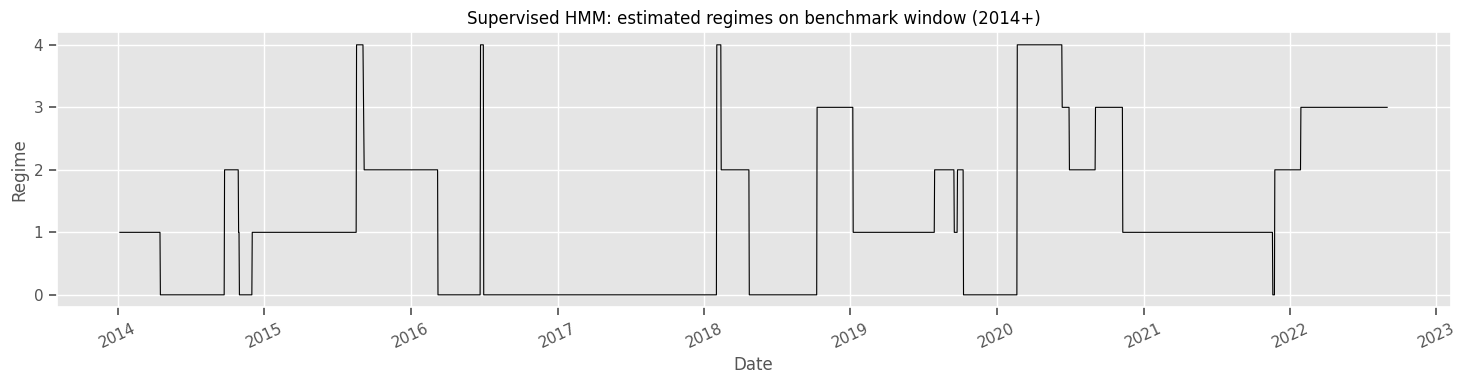

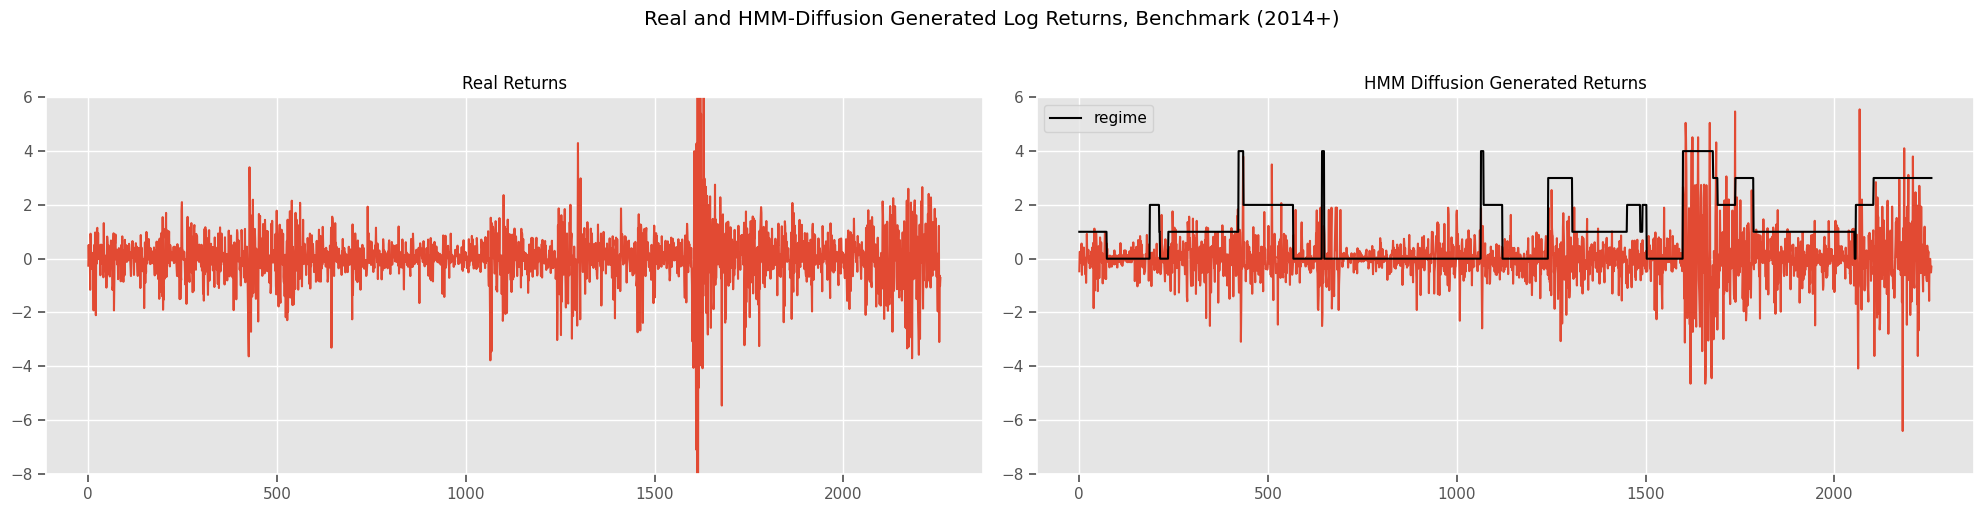

Per-regime moments on benchmark window (estimated regime path)


real                     generated                    
       n_days      mean  variance    n_days      mean  variance
regime                                                         
0         847  0.041601  0.200255       847  0.017748  0.291711
1         680  0.034940  0.437558       680  0.016201  0.385962
2         347 -0.004539  0.916000       347 -0.054693  0.719470
3         278 -0.094456  1.843519       278 -0.014684  1.752163
4         106 -0.245674  8.721549       106 -0.006510  4.921948

In [5]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(benchmark.dates, benchmark.regime_est, color="black", lw=0.8)
ax.set_title(f"Supervised HMM: estimated regimes on benchmark window ({TEST_START_YEAR}+)")
ax.set_xlabel("Date")
ax.set_ylabel("Regime")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

plots.plot_real_vs_generated(
    benchmark.emissions,
    None,
    benchmark.stitched_z,
    benchmark.regime_est,
    generated_title=GENERATED_TITLE,
    suptitle=f"Real and HMM-Diffusion Generated Log Returns, Benchmark ({TEST_START_YEAR}+)",
)

print("Per-regime moments on benchmark window (estimated regime path)")
display(
    pd.concat(
        {
            "real": plots.regime_moments(benchmark.emissions, benchmark.regime_est, N_REGIMES),
            "generated": plots.regime_moments(benchmark.stitched_z, benchmark.regime_est, N_REGIMES),
        },
        axis=1,
    )
)

## Real vs synthetic sanity checks

Both series cover the same 2014+ trading days. The synthetic path is anchored to the real benchmark price on the first shared date. The downstream experiment uses log-price changes, not absolute levels.


Synthetic: 2014-01-06 → 2022-08-31, start price 7,091.52
Real: 2014-01-06 → 2022-08-31, start price 7,091.52


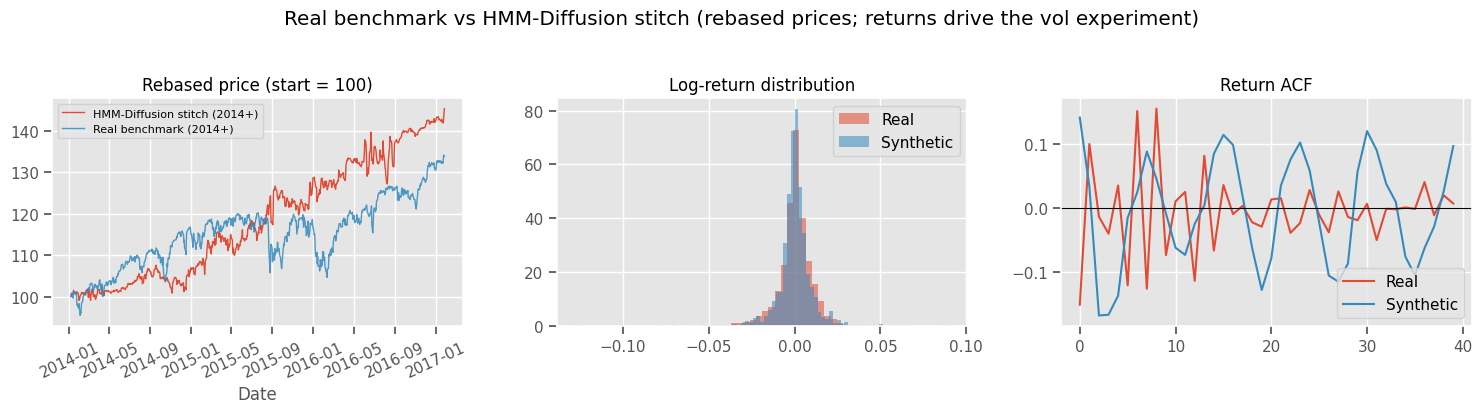

In [6]:
def rebase_to_100(prices: np.ndarray) -> np.ndarray:
    prices = np.asarray(prices, dtype=float)
    return 100.0 * prices / prices[0]


plot_dates = df_real.index[: min(800, len(df_real))]
synth_rebased = rebase_to_100(df_synth.loc[plot_dates, PRICE_COL].values)
real_rebased = rebase_to_100(df_real.loc[plot_dates, PRICE_COL].values)

print(
    f"Synthetic: {df_synth.index.min().date()} → {df_synth.index.max().date()}, "
    f"start price {df_synth[PRICE_COL].iloc[0]:,.2f}"
)
print(
    f"Real: {df_real.index.min().date()} → {df_real.index.max().date()}, "
    f"start price {df_real[PRICE_COL].iloc[0]:,.2f}"
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(plot_dates, synth_rebased, label="HMM-Diffusion stitch (2014+)", lw=1)
axes[0].plot(plot_dates, real_rebased, label=f"Real benchmark ({TEST_START_YEAR}+)", lw=1, alpha=0.85)
axes[0].set_title("Rebased price (start = 100)")
axes[0].set_xlabel("Date")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=25)

axes[1].hist(real_returns_log.values, bins=60, density=True, alpha=0.55, label="Real")
axes[1].hist(synth_returns_log.values, bins=60, density=True, alpha=0.55, label="Synthetic")
axes[1].set_title("Log-return distribution")
axes[1].legend()

max_lag = 40

def acf(x, nlags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[:-lag], x[lag:]) / denom for lag in range(1, nlags + 1)])

axes[2].plot(acf(real_returns_log.values, max_lag), label="Real")
axes[2].plot(acf(synth_returns_log.values, max_lag), label="Synthetic")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("Return ACF")
axes[2].legend()

fig.suptitle(
    "Real benchmark vs HMM-Diffusion stitch (rebased prices; returns drive the vol experiment)",
    y=1.03,
)
fig.tight_layout()
plt.show()

## Volatility mixture experiment

A random forest predicts 21-day realized volatility at horizons of 1, 10, and 20 days ahead from vol, moving average, RSI, and MACD. Training sweeps the synthetic share from 0% to 100%. The test set is always the last 20% of real rows.


Horizon = 1 day(s)
               100 % Real | Test MSE = 0.000001 | R² = +0.971
      9% Synth + 91% Real | Test MSE = 0.000001 | R² = +0.970
     21% Synth + 79% Real | Test MSE = 0.000001 | R² = +0.971
     32% Synth + 68% Real | Test MSE = 0.000002 | R² = +0.964
     40% Synth + 60% Real | Test MSE = 0.000002 | R² = +0.951
     49% Synth + 51% Real | Test MSE = 0.000001 | R² = +0.968
     59% Synth + 41% Real | Test MSE = 0.000001 | R² = +0.976
     70% Synth + 30% Real | Test MSE = 0.000003 | R² = +0.941
     81% Synth + 19% Real | Test MSE = 0.000002 | R² = +0.960
     90% Synth + 10% Real | Test MSE = 0.000002 | R² = +0.967
          100 % Synthetic | Test MSE = 0.000004 | R² = +0.913


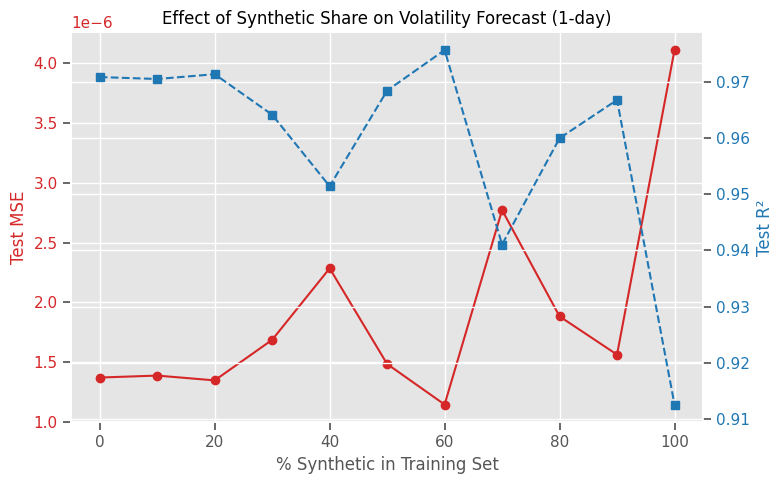

Horizon = 10 day(s)
               100 % Real | Test MSE = 0.000033 | R² = +0.295
      9% Synth + 91% Real | Test MSE = 0.000028 | R² = +0.395
     21% Synth + 79% Real | Test MSE = 0.000024 | R² = +0.490
     32% Synth + 68% Real | Test MSE = 0.000035 | R² = +0.260
     40% Synth + 60% Real | Test MSE = 0.000031 | R² = +0.332
     49% Synth + 51% Real | Test MSE = 0.000030 | R² = +0.364
     59% Synth + 41% Real | Test MSE = 0.000023 | R² = +0.517
     70% Synth + 30% Real | Test MSE = 0.000045 | R² = +0.037
     81% Synth + 19% Real | Test MSE = 0.000026 | R² = +0.451
     90% Synth + 10% Real | Test MSE = 0.000014 | R² = +0.704
          100 % Synthetic | Test MSE = 0.000054 | R² = -0.153


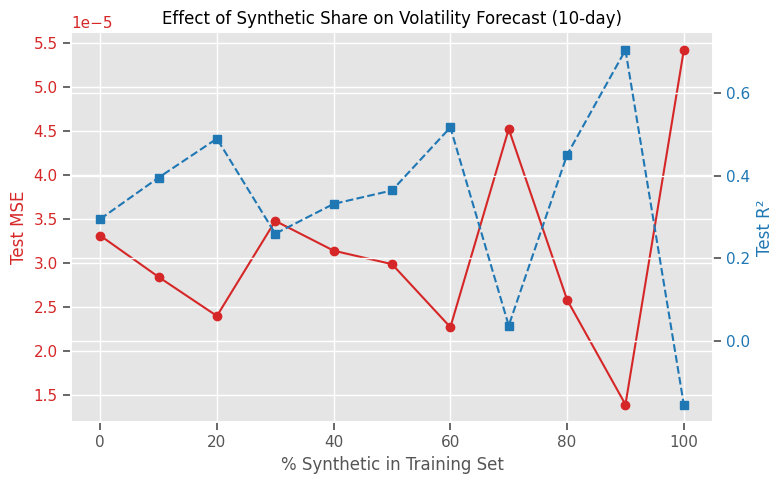

Horizon = 20 day(s)
               100 % Real | Test MSE = 0.000106 | R² = -1.256
      9% Synth + 91% Real | Test MSE = 0.000089 | R² = -0.896
     21% Synth + 79% Real | Test MSE = 0.000088 | R² = -0.872
     32% Synth + 68% Real | Test MSE = 0.000137 | R² = -1.921
     40% Synth + 60% Real | Test MSE = 0.000090 | R² = -0.929
     49% Synth + 51% Real | Test MSE = 0.000072 | R² = -0.540
     59% Synth + 41% Real | Test MSE = 0.000076 | R² = -0.613
     70% Synth + 30% Real | Test MSE = 0.000087 | R² = -0.860
     82% Synth + 18% Real | Test MSE = 0.000087 | R² = -0.860
     90% Synth + 10% Real | Test MSE = 0.000105 | R² = -1.244
          100 % Synthetic | Test MSE = 0.000082 | R² = -0.753


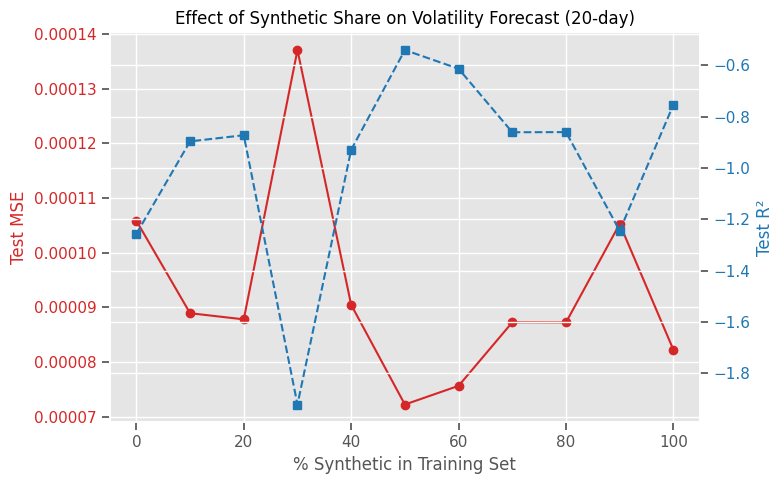

,synthetic_pct,mse,r2,horizon
0,0,0.000001,0.970832,1
1,10,0.000001,0.970487,1
2,20,0.000001,0.971340,1
3,30,0.000002,0.964128,1
4,40,0.000002,0.951418,1


In [7]:
metrics_by_horizon = {}

for horizon in HORIZONS:
    print("=" * 72)
    print(f"Horizon = {horizon} day(s)")
    print("=" * 72)
    metrics_df = train_model_and_evaluate_advanced_volatility_mixture(
        df_real=df_real,
        df_synth=df_synth,
        is_intraday=False,
        price_col=f"{PRICE_COL}_log",
        horizon=horizon,
        show_each_pred_plot=False,
        mix_grid=MIX_GRID,
        random_state=RANDOM_STATE,
        plot_summary=True,
    )
    metrics_df["horizon"] = horizon
    metrics_by_horizon[horizon] = metrics_df

all_metrics = pd.concat(metrics_by_horizon.values(), ignore_index=True)
all_metrics.head()

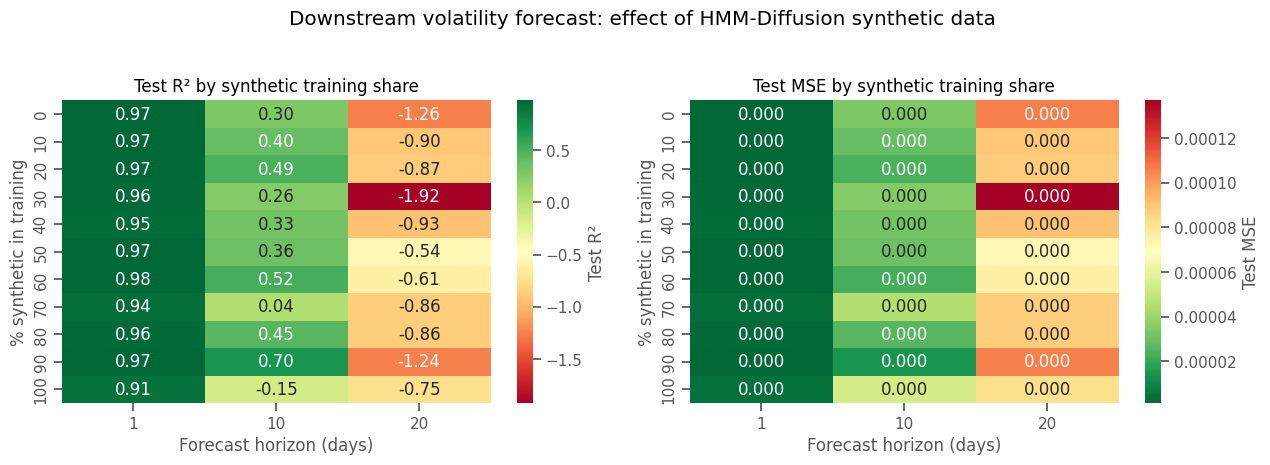

,r2_real_only,r2_synth_only,r2_best_mix,best_mix_pct
horizon,,,,
1,0.971,0.913,0.976,60
10,0.295,-0.153,0.704,90
20,-1.256,-0.753,-0.540,50


In [8]:
pivot_r2 = all_metrics.pivot(index="synthetic_pct", columns="horizon", values="r2")
pivot_mse = all_metrics.pivot(index="synthetic_pct", columns="horizon", values="mse")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(pivot_r2, annot=True, fmt=".2f", cmap="RdYlGn", ax=axes[0], cbar_kws={"label": "Test R²"})
axes[0].set_title("Test R² by synthetic training share")
axes[0].set_xlabel("Forecast horizon (days)")
axes[0].set_ylabel("% synthetic in training")

sns.heatmap(pivot_mse, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=axes[1], cbar_kws={"label": "Test MSE"})
axes[1].set_title("Test MSE by synthetic training share")
axes[1].set_xlabel("Forecast horizon (days)")
axes[1].set_ylabel("% synthetic in training")

fig.suptitle("Downstream volatility forecast: effect of HMM-Diffusion synthetic data", y=1.03)
fig.tight_layout()
plt.show()

summary_rows = []
for horizon, frame in metrics_by_horizon.items():
    real_only = frame.loc[frame["synthetic_pct"] == 0].iloc[0]
    synth_only = frame.loc[frame["synthetic_pct"] == 100].iloc[0]
    best = frame.loc[frame["r2"].idxmax()]
    summary_rows.append(
        {
            "horizon": horizon,
            "r2_real_only": real_only["r2"],
            "r2_synth_only": synth_only["r2"],
            "r2_best_mix": best["r2"],
            "best_mix_pct": int(best["synthetic_pct"]),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("horizon")
display(summary.style.format({
    "r2_real_only": "{:.3f}",
    "r2_synth_only": "{:.3f}",
    "r2_best_mix": "{:.3f}",
}))